<a href="https://colab.research.google.com/github/Fei-Q/dsst389/blob/main/nb/notebook14a.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Notebook14a

### Setup

Run all of the following before starting the notebook.

In [1]:
! wget -q -nc https://raw.githubusercontent.com/taylor-arnold/fds-py/refs/heads/main/funs.py

In [2]:
import numpy as np
import polars as pl

from funs import *
from plotnine import *
from polars import col as c

import torch.nn as nn
import torch.optim as optim

theme_set(theme_minimal())
pl.Config(tbl_rows=25)

ub = "https://raw.githubusercontent.com/taylor-arnold/fds-py-nb/refs/heads/main/"

In [3]:
!wget -nc https://humanitiesdata.org/media/fashionmnist_10000.tar -P media/
!tar -xf media/fashionmnist_10000.tar -C media/
!wget -nc https://humanitiesdata.org/media/emnist_10000.tar -P media/
!tar -xf media/emnist_10000.tar -C media/

--2026-04-01 13:40:30--  https://humanitiesdata.org/media/fashionmnist_10000.tar
Resolving humanitiesdata.org (humanitiesdata.org)... 51.222.48.183
Connecting to humanitiesdata.org (humanitiesdata.org)|51.222.48.183|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 23183360 (22M) [application/x-tar]
Saving to: ‘media/fashionmnist_10000.tar’

fashionmnist_10000. 100%[===================>]  22.11M  14.7MB/s    in 1.5s    

2026-04-01 13:40:57 (14.7 MB/s) - ‘media/fashionmnist_10000.tar’ saved [23183360/23183360]

--2026-04-01 13:40:58--  https://humanitiesdata.org/media/emnist_10000.tar
Resolving humanitiesdata.org (humanitiesdata.org)... 51.222.48.183
Connecting to humanitiesdata.org (humanitiesdata.org)|51.222.48.183|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20828160 (20M) [application/x-tar]
Saving to: ‘media/emnist_10000.tar’

emnist_10000.tar    100%[===================>]  19.86M  15.5MB/s    in 1.3s    

2026-04-01 13:41:15 (1

In [4]:
fmnist = pl.read_csv(ub + "data/fashionmnist_10000.csv")
emnist = pl.read_csv(ub + "data/emnist_10000.csv")

### Part I: Fashion MNIST

1. Use the code below to create the training and testing data. Notice this time that the shape of the data has changed. Make sure you understand what this means.

In [5]:
X, X_train, X_test, y, y_train, y_test, cn = DSTorch.load_image(
    fmnist, scale=True
)
X.shape

torch.Size([10000, 1, 28, 28])

2. Next, use the following code to build a CNN model. Go through the parameters to understand the shape of the model.

In [6]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.net(x)

3. As before, we will use the Adam optimizer. After a little trial and error for the above parameters, I found a slightly higher learning rate (0.003) compared to last time was ideal.

In [7]:
model = SimpleCNN()
optimizer = optim.Adam(model.parameters(), lr=0.003)

4. Train the model. Notice that that the training loss will be worse because of the dropout, but it should help avoid overfitting.

In [8]:
DSTorch.train(
    model, optimizer, X_train, y_train, num_epochs=20, batch_size=64
)

Epoch 1/20, Loss: 0.7891
Epoch 2/20, Loss: 0.5118
Epoch 3/20, Loss: 0.4579
Epoch 4/20, Loss: 0.4152
Epoch 5/20, Loss: 0.3726
Epoch 6/20, Loss: 0.3632
Epoch 7/20, Loss: 0.3407
Epoch 8/20, Loss: 0.3174
Epoch 9/20, Loss: 0.3188
Epoch 10/20, Loss: 0.2885
Epoch 11/20, Loss: 0.2819
Epoch 12/20, Loss: 0.2626
Epoch 13/20, Loss: 0.2519
Epoch 14/20, Loss: 0.2506
Epoch 15/20, Loss: 0.2503
Epoch 16/20, Loss: 0.2436
Epoch 17/20, Loss: 0.2292
Epoch 18/20, Loss: 0.2150
Epoch 19/20, Loss: 0.2146
Epoch 20/20, Loss: 0.2111


5. Look at the scores and confusion matrix of the training and testing sets. You will probably notice that the model does a bit better than the dense network, but the biggest improvement here is the dropout stopping the model from overfitting the training data.

In [9]:
DSTorch.score_image(model, X_train, y_train, cn)

0.9426666498184204

In [10]:
DSTorch.score_image(model, X_test, y_test, cn)

0.8867999911308289

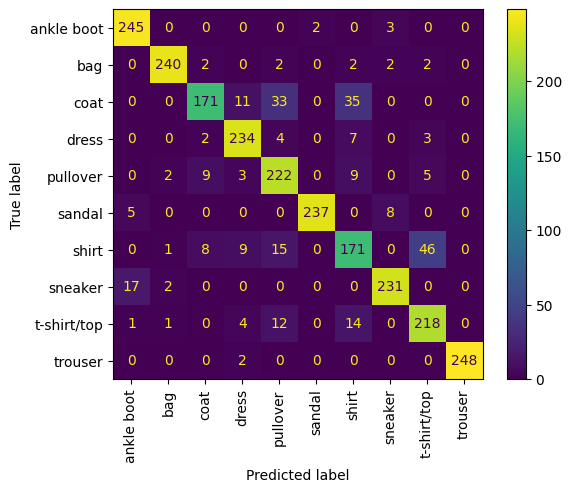

In [11]:
DSTorch.confusion_matrix(model, X_test, y_test, cn)

6. Finally, let's look at the negative examples. How easily can *you* tell them apart?

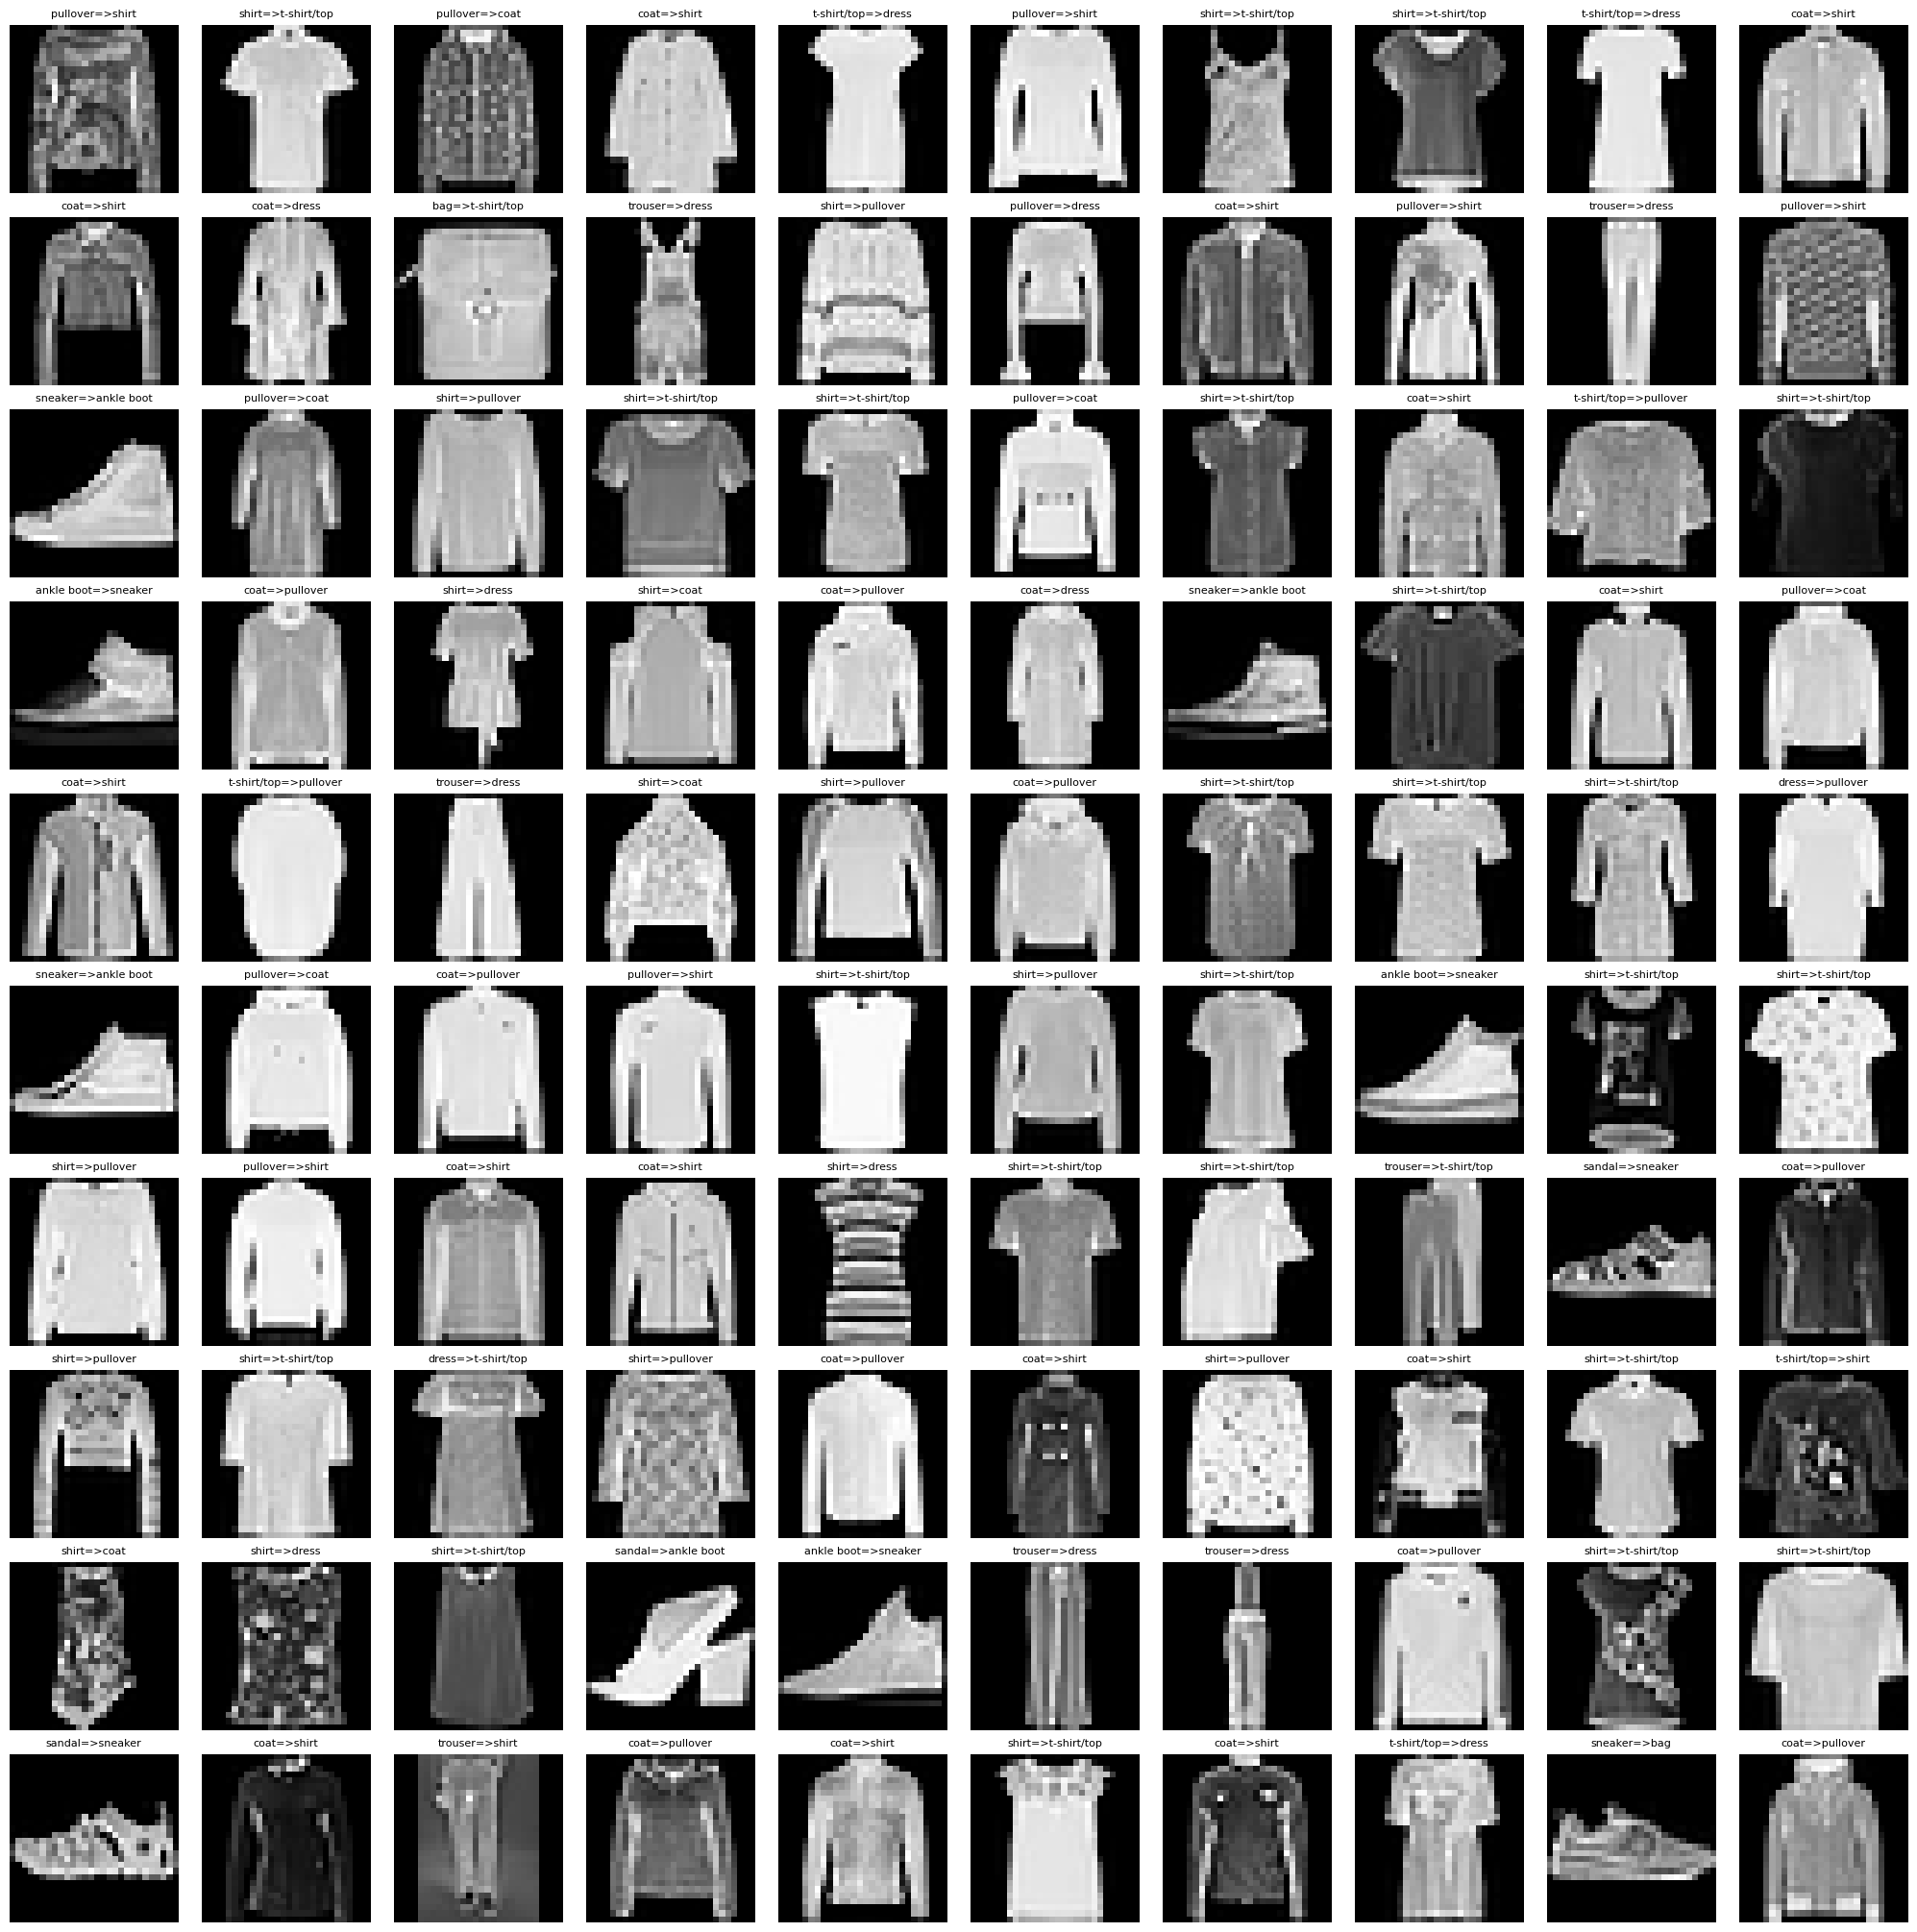

In [12]:
(
    fmnist
    .with_columns(
        DSTorch.predict(model, X, y, cn)
    )
    .filter(c.target_ != c.prediction_)
    .with_columns(
        info = pl.concat_str(c.target_, c.prediction_, separator="=>")
    )
    .pipe(DSImage.plot_image_grid, label_name="info")
)

### Part II: EMNIST

7. Now look at the EMNIST dataset. We follow the same instructions as above, though the results themselves will be a bit different.

In [13]:
X, X_train, X_test, y, y_train, y_test, cn = DSTorch.load_image(
    emnist, scale=True
)
X.shape

torch.Size([10000, 1, 28, 28])

8. Next, use the following code to build a CNN model. Go through the parameters to understand the shape of the model.

In [14]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.net(x)

9. As before, we will use the Adam optimizer.

In [15]:
model = SimpleCNN(num_classes=len(cn))
optimizer = optim.Adam(model.parameters(), lr=0.003)

10. Train the model. Notice that that the training loss will be worse because of the dropout, but it should help avoid overfitting.

In [16]:
DSTorch.train(
    model, optimizer, X_train, y_train, num_epochs=20, batch_size=64
)

Epoch 1/20, Loss: 2.0641
Epoch 2/20, Loss: 0.9529
Epoch 3/20, Loss: 0.7345
Epoch 4/20, Loss: 0.6310
Epoch 5/20, Loss: 0.5626
Epoch 6/20, Loss: 0.5215
Epoch 7/20, Loss: 0.4922
Epoch 8/20, Loss: 0.4535
Epoch 9/20, Loss: 0.4222
Epoch 10/20, Loss: 0.4113
Epoch 11/20, Loss: 0.3865
Epoch 12/20, Loss: 0.3727
Epoch 13/20, Loss: 0.3494
Epoch 14/20, Loss: 0.3459
Epoch 15/20, Loss: 0.3421
Epoch 16/20, Loss: 0.3459
Epoch 17/20, Loss: 0.3197
Epoch 18/20, Loss: 0.2944
Epoch 19/20, Loss: 0.3080
Epoch 20/20, Loss: 0.2820


11. Look at the scores of the training and testing sets. You will probably notice that the model does a bit better than the dense network, but the biggest improvement here is the dropout stopping the model from overfitting the training data.

In [17]:
DSTorch.score_image(model, X_train, y_train, cn)

0.9298666715621948

In [18]:
DSTorch.score_image(model, X_test, y_test, cn)

0.800000011920929

12. Let's look at the negative examples. How easily can *you* tell them apart?

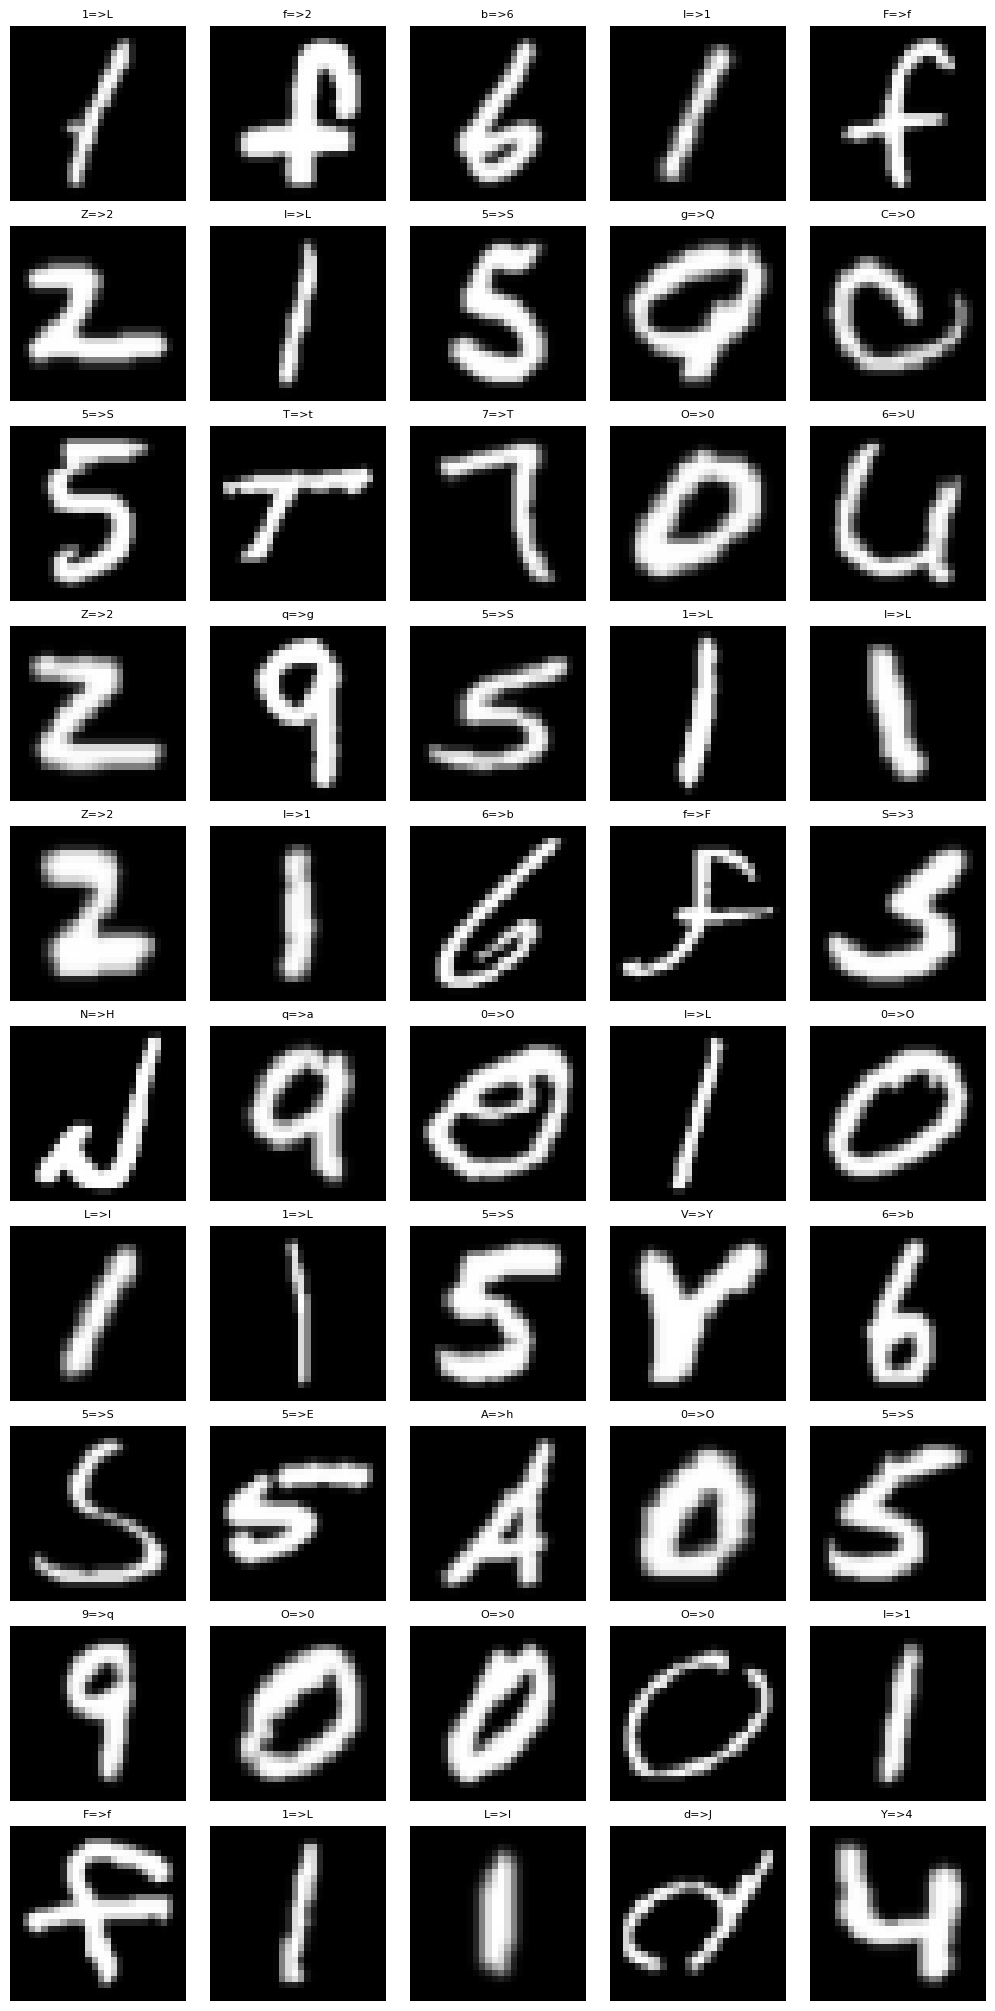

In [19]:
(
    emnist
    .with_columns(
        DSTorch.predict(model, X, y, cn)
    )
    .filter(c.target_ != c.prediction_)
    .sample(50)
    .with_columns(
        info = pl.concat_str(c.target_, c.prediction_, separator="=>")
    )
    .pipe(DSImage.plot_image_grid, label_name="info", ncol=5)
)

### Part III: EMNIST Metrics

Now for some coding on your own. We'll create a version of the emnist dataset with the predictions and then build some metrics for the data.

In [20]:
emnist_pred = (
    emnist
    .with_columns(
        DSTorch.predict(model, X, y, cn)
    )
)

13.  The confusion matrix for this example is a bit too large to print (at least with the default settings in our code). Instead, in the block below, compute how often two pairs of labels are confused, as sort in descending order. You should see the most commonly confused pairs are quite reasonable.

In [21]:
(
    emnist_pred
    .filter(c.target_ != c.prediction_)
    .group_by(c.target_, c.prediction_)
    .agg(count = pl.len())
    .sort(c.count, descending=True)
)

target_,prediction_,count
str,str,u32
"""5""","""S""",88
"""F""","""f""",72
"""0""","""O""",59
"""1""","""L""",55
"""L""","""1""",47
"""q""","""9""",45
"""O""","""0""",42
"""I""","""1""",41
"""Z""","""2""",30


14. Now, create a dataset `df_recall` that has the recall of each class. Remember, this is, for each class, the proportion of items that were correctly predicted.

In [22]:
df_recall = (
    emnist_pred
    .group_by(c.target_)
    .agg(recall = (c.target_ == c.prediction_).mean())
)
df_recall

target_,recall
str,f64
"""3""",0.971698
"""H""",0.985915
"""F""",0.629108
"""U""",0.957746
"""I""",0.661972
"""W""",0.976526
"""P""",0.985915
"""X""",0.953052
"""a""",0.948113


15. Now, create a dataset `df_recall` that has the recall of each class. Remember, this is, for each class, the proportion of items that were predicted to be that class that were correct. You should notice that this is very similar to the code from the previous question.

In [25]:
df_precision = (
    emnist_pred
    .group_by(c.prediction_)
    .agg(precision = (c.target_ == c.prediction_).mean())
)
df_precision

prediction_,precision
str,f64
"""I""",0.770492
"""T""",0.966825
"""S""",0.682848
"""3""",0.980952
"""Y""",0.945813
"""a""",0.922018
"""K""",0.967136
"""G""",0.901288
"""b""",0.885593


16. Join the precision and recall tables, compute the F1 scores, sort by the F1 scores, and print out all of the rows.

In [26]:
(
    df_recall
    .join(df_precision, left_on="target_", right_on="prediction_")
    .with_columns(
        f1 = 2 * (c.precision * c.recall) / (c.precision + c.recall)
    )
    .sort(c.f1)
    .pipe(print_rows)
)

target_,recall,precision,f1
str,f64,f64,f64
"""1""",0.647887,0.60262,0.624434
"""L""",0.636792,0.616438,0.62645
"""q""",0.641509,0.777143,0.702842
"""0""",0.674528,0.740933,0.706173
"""I""",0.661972,0.770492,0.712121
"""5""",0.57277,0.99187,0.72619
"""F""",0.629108,0.875817,0.73224
"""O""",0.788732,0.72103,0.753363
"""9""",0.834906,0.731405,0.779736
